Poids prédit : 51.72131147540982


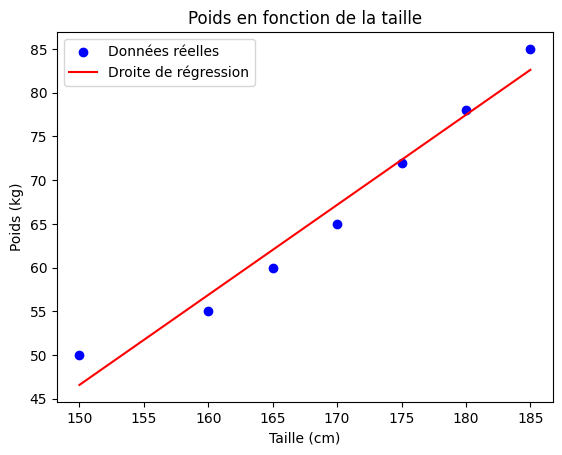

In [1]:
# regression_simple_sklearn.py

# Import du modèle de régression linéaire
from sklearn.linear_model import LinearRegression

# Import des bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt

# Données d'entrée (taille)
x = np.array([150, 160, 165, 170, 175, 180, 185]).reshape(-1, 1)

# Données de sortie (poids)
y = np.array([50, 55, 60, 65, 72, 78, 85])

# Création du modèle
model = LinearRegression()

# Entraînement du modèle
model.fit(x, y)

# Nouvelle valeur à prédire
taille = np.array([[155]])

# Prédiction du poids
poids = model.predict(taille)

# Affichage du résultat
print("Poids prédit :", poids[0])

# Affichage graphique
plt.scatter(x, y, color='blue', label='Données réelles')
plt.plot(x, model.predict(x), color='red', label='Droite de régression')
plt.xlabel('Taille (cm)')
plt.ylabel('Poids (kg)')
plt.title('Poids en fonction de la taille')
plt.legend()
plt.show()


In [3]:
# regression_simple_scratch.py

import numpy as np

# Données
X = np.array([150, 160, 165, 170, 175, 180, 185])
y = np.array([50, 55, 60, 65, 72, 78, 85])

# Calcul des moyennes
x_mean = np.mean(X)
y_mean = np.mean(y)

# Calcul de la pente (b1)
num = np.sum((X - x_mean) * (y - y_mean))
den = np.sum((X - x_mean) ** 2)
b1 = num / den

# Calcul de l'intercept (b0)
b0 = y_mean - b1 * x_mean

# Affichage des coefficients
print("b0 =", b0)
print("b1 =", b1)

# Prédiction
prediction = b0 + b1 * 155
print("Poids prédit :", prediction)

b0 = -107.85245901639344
b1 = 1.0295081967213116
Poids prédit : 51.72131147540985


Poids prédit : 54.400000000000006


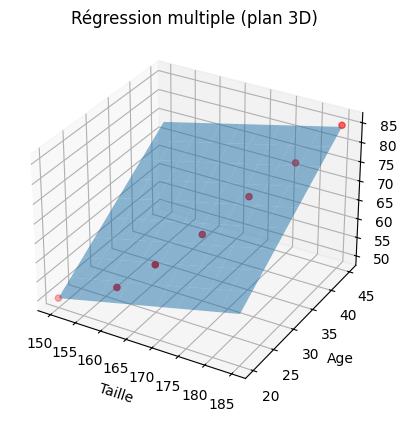

In [7]:
# regression_multiple_sklearn.py

from sklearn.linear_model import LinearRegression  # Import du modèle de régression linéaire
import numpy as np  # Import de NumPy pour manipuler les tableaux
import matplotlib.pyplot as plt  # Import de matplotlib pour les graphiques
from mpl_toolkits.mplot3d import Axes3D  # Import pour les graphiques en 3D

# Données : [taille, âge]
X = np.array([  # Création d’un tableau 2D contenant les variables explicatives
    [150, 20],  # Exemple 1 : taille=150, âge=20
    [160, 22],
    [165, 25],
    [170, 30],
    [175, 35],
    [180, 40],
    [185, 45]
])

# Poids
y = np.array([50, 55, 60, 65, 72, 78, 85])  # Variable cible (ce qu’on veut prédire)

# Création du modèle
model = LinearRegression()  # Instanciation du modèle de régression linéaire

# Entraînement
model.fit(X, y)  # Apprentissage du modèle à partir des données (X → y)

# Nouvelle personne
personne = np.array([[155, 23]])  # Données d’une nouvelle personne (taille, âge)

# Prédiction
poids = model.predict(personne)  # Prédiction du poids pour cette personne

# Affichage
print("Poids prédit :", poids[0])  # Affiche le résultat (poids estimé)

# Création d'une figure
fig = plt.figure()  # Initialise une figure pour le graphique

# Ajout d'un axe 3D
ax = fig.add_subplot(111, projection='3d')  # Ajoute un axe en 3D à la figure

# Scatter des données réelles
ax.scatter(X[:, 0], X[:, 1], y, color='red')
# Affiche les points réels : X[:,0]=taille, X[:,1]=âge, y=poids

# Création grille
taille_range = np.linspace(X[:,0].min(), X[:,0].max(), 10)
# Génère 10 valeurs de taille entre min et max

age_range = np.linspace(X[:,1].min(), X[:,1].max(), 10)
# Génère 10 valeurs d’âge entre min et max

X_grid, Y_grid = np.meshgrid(taille_range, age_range)
# Crée une grille 2D à partir des tailles et âges

# Prédictions sur la grille
Z = model.predict(np.c_[X_grid.ravel(), Y_grid.ravel()])
# Prédit le poids pour chaque point de la grille

Z = Z.reshape(X_grid.shape)
# Remet Z sous forme de grille (comme X_grid)

# Plan de régression
ax.plot_surface(X_grid, Y_grid, Z, alpha=0.5)
# Trace la surface (plan de régression)

# Labels
ax.set_xlabel("Taille")  # Nom de l’axe X
ax.set_ylabel("Age")     # Nom de l’axe Y
ax.set_zlabel("Poids")   # Nom de l’axe Z

# Titre du graphique
plt.title("Régression multiple (plan 3D)")

# Affichage du graphique
plt.show()  # Affiche la figure

In [8]:
# regression_multiple_scratch.py

import numpy as np

# Données
X = np.array([
    [150, 20],
    [160, 22],
    [165, 25],
    [170, 30],
    [175, 35],
    [180, 40],
    [185, 45]
])

y = np.array([50, 55, 60, 65, 72, 78, 85])

# Ajout d'une colonne de 1 pour le biais
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Calcul des coefficients avec l'équation normale
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Nouvelle donnée (avec biais)
personne = np.array([1, 155, 23])

# Prédiction
poids = personne.dot(theta)

# Affichage
print("Poids prédit :", poids)


Poids prédit : 54.399999999988495


Poids prédit : 52.28925619834558


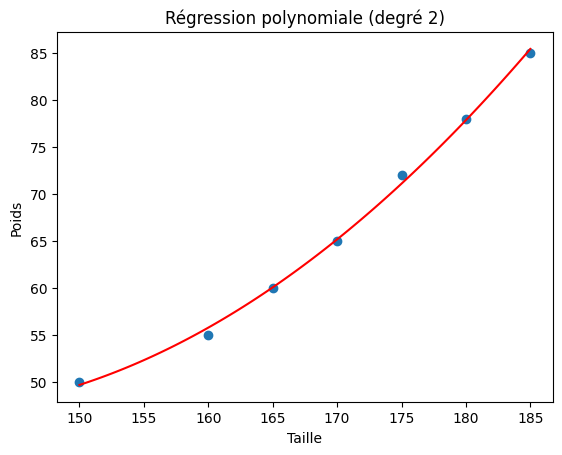

In [11]:
# regression_polynomiale_sklearn.py

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt  # Pour afficher la courbe

# Données
x = np.array([150, 160, 165, 170, 175, 180, 185]).reshape(-1,1)
y = np.array([50, 55, 60, 65, 72, 78, 85])

# Transformation en polynôme degré 2
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

# Modèle
model = LinearRegression()

# Entraînement
model.fit(x_poly, y)

# Prédiction
poids = model.predict(poly.transform([[155]]))

# Affichage
print("Poids prédit :", poids[0])


# Points réels
plt.scatter(x, y)

# Générer des valeurs lisses pour la courbe
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1,1)

# Transformation polynomiale
x_range_poly = poly.transform(x_range)

# Prédictions pour la courbe
y_range = model.predict(x_range_poly)

# Tracer la courbe
plt.plot(x_range, y_range,color='red')

# Labels
plt.xlabel("Taille")
plt.ylabel("Poids")
plt.title("Régression polynomiale (degré 2)")

# Affichage
plt.show()

In [12]:
# regression_polynomiale_scratch.py

import numpy as np

# Données
x = np.array([150, 160, 165, 170, 175, 180, 185])
y = np.array([50, 55, 60, 65, 72, 78, 85])

# Création des variables : 1, x, x²
X_poly = np.c_[np.ones(len(x)), x, x**2]

# Calcul des coefficients
theta = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)

# Prédiction pour x = 155
x_new = np.array([1, 155, 155**2])
poids = x_new.dot(theta)

# Affichage
print("Poids prédit :", poids)


Poids prédit : 52.28925619755046
